In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [12]:
# Select the features 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS' 
# to use for building the model. Plot Emission values with respect to Engine size.

df = pd.read_csv("FuelConsumption.csv")
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]

print("\nFIRST FIVE RECORDS") 
print(df.head()) 
print("\nDATASET SHAPE") 
print(df.shape) 
print("\nCOLUMN NAMES") 
print(df.columns.tolist()) 
print("\nDATA TYPES AND NON-NULL COUNTS") 
df.info() 
print("\nMISSING VALUES") 
print(df.isnull().sum()) 
print("\nDUPLICATE ROWS:", df.duplicated().sum()) 
print("\nDESCRIPTIVE STATISTICS") 
print(df.describe().T)


FIRST FIVE RECORDS
   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           196  


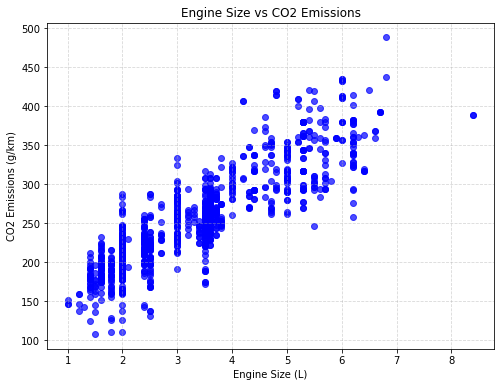

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(cdf['ENGINESIZE'], cdf['CO2EMISSIONS'], color='blue', alpha=0.7)
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")
plt.title("Engine Size vs CO2 Emissions")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [16]:
# split the data into training and test sets (70:30) to create a model 
# using training set, evaluate the model using test set, and use model to predict unknown value

X = cdf[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

mlr = LinearRegression()
mlr.fit(X_train, y_train)

print("--- Model Parameters ---")
print(f"Coefficients (Slopes for Engine Size, Cylinders, Fuel Consumption): {mlr.coef_}")
print(f"Intercept: {mlr.intercept_:.2f}\n")

y_pred = mlr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Residual Sum of Squares (MSE): {mse:.2f}")
print(f"R2-Score: {r2:.4f}\n")

# 6. Predict an unknown value using a DataFrame
# Example input: [Engine Size = 3.5L, Cylinders = 6, Combined Fuel Consumption = 11.1 L/100km]
unknown_car = pd.DataFrame([[3.5, 6, 11.1]], columns=['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB'])
predicted_co2 = mlr.predict(unknown_car)

print("--- Prediction for Unknown Car ---")
print(f"Predicted CO2 Emissions: {predicted_co2[0]:.2f} g/km")


Training set size: 746 rows
Test set size: 321 rows
--- Model Parameters ---
Coefficients (Slopes for Engine Size, Cylinders, Fuel Consumption): [10.91586089  7.074642    9.69391531]
Intercept: 66.77

--- Model Evaluation ---
Mean Absolute Error (MAE): 16.54
Residual Sum of Squares (MSE): 503.60
R2-Score: 0.8751

--- Prediction for Unknown Car ---
Predicted CO2 Emissions: 255.03 g/km


In [15]:
# Try to use a polynomial regression with the dataset of degree – 3, 4 & 5. 
# Verify the accuracy by calculating Mean absolute error, Residual sum of squares, 
# R2-score and comment on which model is the best.

degrees = [3, 4, 5]
results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)
    
    y_pred = poly_reg.predict(X_test_poly)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[degree] = {'MAE': mae, 'MSE': mse, 'R2': r2}
    
    print(f"--- Degree {degree} Model ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Residual Sum of Squares (MSE): {mse:.2f}")
    print(f"R2-Score: {r2:.4f}\n")

--- Degree 3 Model ---
Mean Absolute Error (MAE): 22.80
Residual Sum of Squares (MSE): 879.27
R2-Score: 0.7820

--- Degree 4 Model ---
Mean Absolute Error (MAE): 22.74
Residual Sum of Squares (MSE): 880.96
R2-Score: 0.7816

--- Degree 5 Model ---
Mean Absolute Error (MAE): 22.81
Residual Sum of Squares (MSE): 882.04
R2-Score: 0.7813



The MAE is the least in degree 4 model, while the MSE is the least in degree 3 model. R2 Score is the highest in degree 3 model. Hence degree 3 model is the best among the 3.